# CV Project 2 — Gradient Domain Editing & Geometric Transformations

| Phần | Nội dung |
|------|----------|
| **Phần 1** | Gradient Domain Editing — ghép ảnh tự nhiên qua miền gradient |
| **Phần 2** | Geometric Transformations — các phép biến đổi hình học |
| **Mở rộng** | Image Warping — dán ảnh lên mặt phẳng thực tế |

---
# Phần 1: Gradient Domain Editing

## 1. Import thư viện

In [ ]:
import cv2                              # Xử lý ảnh
import requests                         # Tải ảnh từ URL
from io import BytesIO                  # Đọc dữ liệu nhị phân từ response
from PIL import Image                   # Mở và resize ảnh
import numpy as np                      # Tính toán ma trận
from google.colab.patches import cv2_imshow  # Hiển thị ảnh trong Colab
from scipy.sparse import lil_matrix     # Ma trận thưa (sparse matrix)
from scipy.sparse.linalg import spsolve # Giải hệ phương trình tuyến tính thưa


## 2. Load ảnh đầu vào

In [ ]:
# Tải ảnh nguồn (source) từ GitHub
image_url = 'https://raw.githubusercontent.com/HKRM1006/image/main/source.png'
response = requests.get(image_url)
response.raise_for_status()
source = Image.open(BytesIO(response.content))

# Resize còn 1/2 để giảm kích thước xử lý
W, H = source.size
source = source.resize((int(W/2), int(H/2)))

# Tải ảnh nền (background/destination) từ GitHub
image_url = 'https://raw.githubusercontent.com/HKRM1006/image/main/dist.png'
response = requests.get(image_url)
response.raise_for_status()
dist = Image.open(BytesIO(response.content))

# Chuyển sang numpy array BGR (định dạng OpenCV)
source_np = cv2.cvtColor(np.array(source), cv2.COLOR_RGB2BGR)
dist_np   = cv2.cvtColor(np.array(dist),   cv2.COLOR_RGB2BGR)

display(source)
display(dist)


## 3. Xác định mask

In [ ]:
# Bước 1: Chuyển ảnh nguồn sang grayscale
gray = cv2.cvtColor(source_np, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

# Bước 2: Tạo mask nhị phân bằng Otsu threshold
# Otsu tự động tìm ngưỡng tối ưu dựa trên histogram của ảnh
# Pixel sáng hơn ngưỡng → 255 (vật thể), tối hơn → 0 (nền)
_, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2_imshow(mask)

# Bước 3: Dilate mask để bao quát toàn bộ vật thể và phần viền xung quanh
# Đảm bảo seamlessClone nhận đủ vùng cần blend tại biên
kernel = np.ones((5, 5), np.uint8)
mask = cv2.dilate(mask, kernel, iterations=3)
cv2_imshow(mask)


## 4. Ghép ảnh

In [ ]:
# Xác định vị trí trung tâm để đặt ảnh nguồn vào ảnh nền
h_dist, w_dist, _ = dist_np.shape
h_mask, w_mask, _ = source_np.shape
center = (int(w_dist/2), int(h_dist/2))
x = center[0] - int(w_mask/2)
y = center[1] - int(h_mask/2)

# Phương pháp 1: Naive copy-paste — sao chép trực tiếp pixel theo mask
image = dist_np.copy()
roi = image[y:y+h_mask, x:x+w_mask]
roi[mask>0] = source_np[mask>0]
image[y:y+h_mask, x:x+w_mask] = roi
image_naive = image.copy()  # lưu lại để so sánh
cv2_imshow(image_naive)

# Phương pháp 2: Gradient Domain Editing với seamlessClone
# NORMAL_CLONE: giải phương trình Poisson với guidance field lấy từ gradient ảnh nguồn
# Kết quả: chi tiết vật thể được giữ nguyên, màu sắc tự động hòa hợp với nền
image_gde = cv2.seamlessClone(source_np, dist_np, mask, center, cv2.NORMAL_CLONE)
cv2_imshow(image_gde)


## 5. So sánh kết quả

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('So sánh các phương pháp ghép ảnh', fontsize=14, fontweight='bold')

pairs = [
    (dist_np,     'Ảnh nền gốc'),
    (image_naive, 'Naive Copy-Paste'),
    (image_gde,   'Gradient Domain Editing\n(NORMAL_CLONE)'),
]
for ax, (img, title) in zip(axes, pairs):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()


---
# Phần 2: Biến đổi hình học (Geometric Transformations)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh và chuyển đổi hệ màu BGR (mặc định của OpenCV) sang RGB (để hiển thị đúng trên Matplotlib)
path='sample1.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Lấy kích thước ảnh
rows, cols, ch = img.shape
print(f"Đã tải ảnh thành công! Kích thước ảnh: {rows}x{cols}")

Đã tải ảnh thành công! Kích thước ảnh: 337x600


## 1. Các phép biến đổi cơ bản (Translation, Rotation, Scaling)
Các phép biến đổi phẳng này thường được biểu diễn thông qua các ma trận $2 \times 3$.
* **Translation (Tịnh tiến):** Dịch chuyển các điểm ảnh theo trục X và Y.
* **Rotation (Quay):** Xoay ảnh quanh một tâm điểm với một góc xác định.
* **Scaling (Thu phóng):** Phóng to hoặc thu nhỏ ảnh.

In [38]:
# --- 1. Translation (Dịch chuyển) ---
# Dịch chuyển sang phải 50 pixel, xuống dưới 30 pixel
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
dst_trans = cv2.warpAffine(img, M_trans, (cols, rows))

# --- 2. Rotation (Xoay) ---
# Xoay 45 độ ngược chiều kim đồng hồ quanh tâm ảnh, thu nhỏ còn 80%
center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 0.8)
dst_rot = cv2.warpAffine(img, M_rot, (cols, rows))

# --- 3. Scaling (Thu phóng) ---
# Phóng to gấp 1.2 lần theo cả trục x và y
dst_scale = cv2.resize(img, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_LINEAR)

## 2. Affine Transformation và Projective Transformation
Hai phép biến đổi nâng cao này có sự khác biệt rõ rệt về ma trận biểu diễn, số bậc tự do và tính chất hình học.
* **Affine Transformation:** Sử dụng ma trận $2 \times 3$ (6 bậc tự do) và cần 3 cặp điểm tham chiếu. Phép biến đổi này **luôn bảo toàn tính song song** của các đường thẳng (biến hình chữ nhật thành hình bình hành).
* **Projective Transformation (Homography):** Sử dụng ma trận $3 \times 3$ (8 bậc tự do) và cần 4 cặp điểm tham chiếu. Phép biến đổi này **không bảo toàn tính song song** (biến hình chữ nhật thành tứ giác bất kỳ), cho phép tạo ra các hiệu ứng phối cảnh xa gần.

In [39]:
# --- 4. Affine Transformation ---
# Cần 3 điểm: Chọn 3 góc của ảnh (Trên-trái, Trên-phải, Dưới-trái)
pts1_aff = np.float32([[0, 0], [cols-1, 0], [0, rows-1]])
# Di chuyển 3 điểm này tới vị trí mới để tạo độ xiên
pts2_aff = np.float32([[cols*0.1, rows*0.2], [cols*0.9, rows*0.1], [cols*0.2, rows*0.9]])

M_aff = cv2.getAffineTransform(pts1_aff, pts2_aff)
dst_affine = cv2.warpAffine(img, M_aff, (cols, rows))

# --- 5. Projective Transformation (Homography) ---
# Cần 4 điểm: Chọn 4 góc của ảnh
pts1_proj = np.float32([[0, 0], [cols-1, 0], [0, rows-1], [cols-1, rows-1]])
# Kéo 4 góc này thành một tứ giác tạo cảm giác chiều sâu (phối cảnh 3D)
# pts2_proj = np.float32([[cols*0.2, rows*0.2], [cols-1, rows*0.0], [cols*0.0, rows*0.6], [cols*0.8, rows-1]])
pts2_proj = np.float32([[cols*0.4, rows*0.1], [cols*0.6, rows*0.15], [cols*0.05, rows*0.9], [cols-1, rows-1]])
M_proj = cv2.getPerspectiveTransform(pts1_proj, pts2_proj)
dst_projective = cv2.warpPerspective(img, M_proj, (cols, rows))

## 3. Trực quan hóa và Đánh giá kết quả
Đoạn mã dưới đây sử dụng `matplotlib` để hiển thị tất cả các kết quả trên cùng một khung hình nhằm so sánh trực quan. Hãy chú ý đến hình lưới của Sudoku:
* Trong ảnh **Affine**, các đường kẻ caro ban đầu song song thì sau khi biến đổi **vẫn tiếp tục song song**.
* Trong ảnh **Projective**, các đường kẻ caro ban đầu song song giờ đã **cắt nhau tại điểm tụ** (vanishing point), tạo ra ảo giác về không gian 3 chiều.

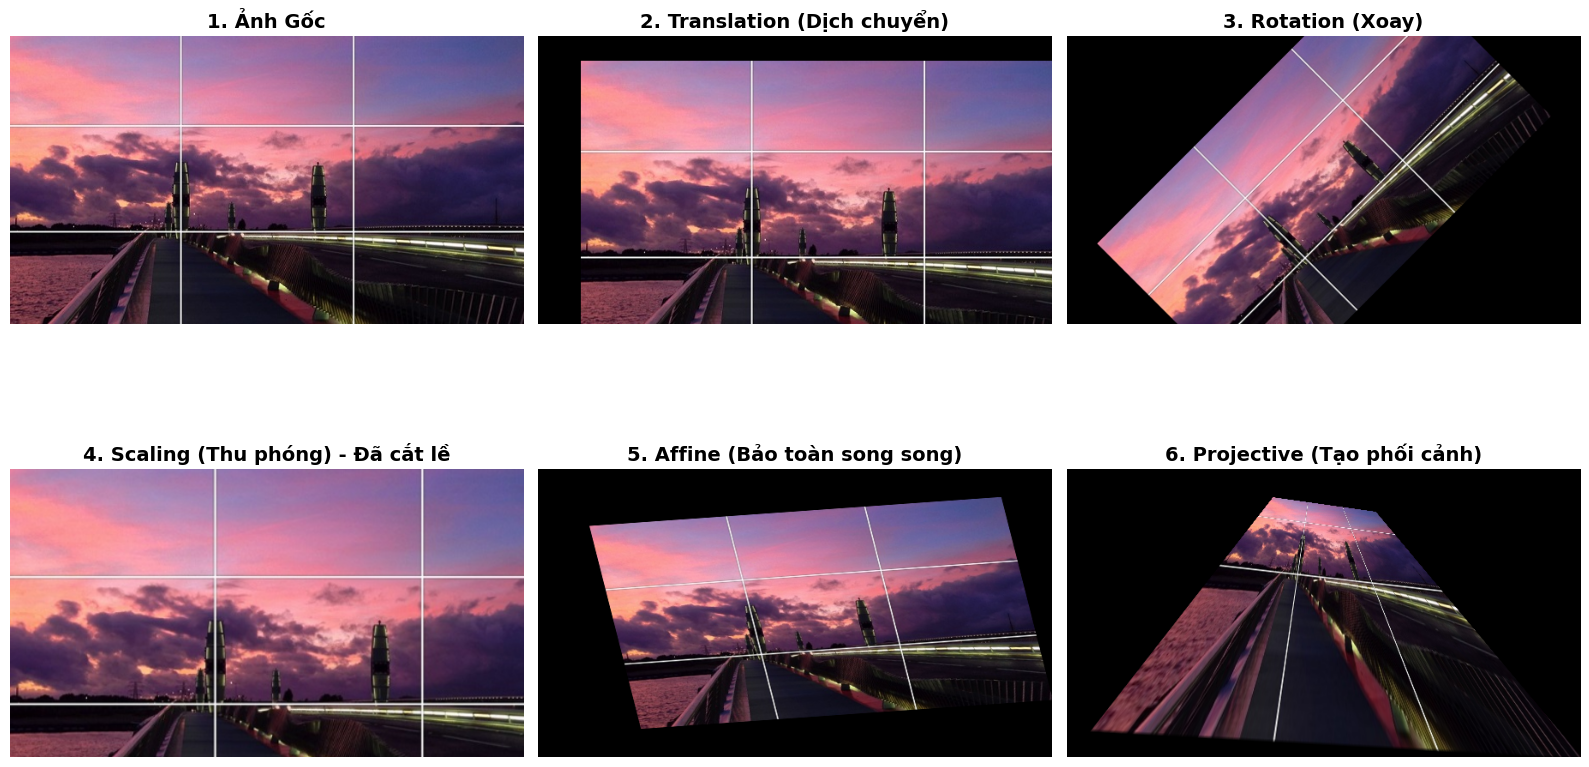

In [40]:
# Thiết lập danh sách ảnh và tiêu đề
images = [img, dst_trans, dst_rot, dst_scale, dst_affine, dst_projective]
titles = ['1. Ảnh Gốc', '2. Translation (Dịch chuyển)', '3. Rotation (Xoay)', 
          '4. Scaling (Thu phóng) - Đã cắt lề', '5. Affine (Bảo toàn song song)', '6. Projective (Tạo phối cảnh)']

# Vẽ hình
plt.figure(figsize=(16, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    
    # Đối với ảnh scaling kích thước to hơn, ta cắt lại cho bằng ảnh gốc để dễ hiển thị
    if i == 3: 
        plt.imshow(images[i][0:rows, 0:cols])
    else:
        plt.imshow(images[i])
        
    plt.title(titles[i], fontsize=14, fontweight='bold')
    plt.axis('off') # Ẩn trục tọa độ

plt.tight_layout()
plt.show()

## 4. Đánh giá hiệu quả và hạn chế của các phép biến đổi cơ bản
Trong Computer Vision (CV), các phép biến đổi như Tịnh tiến (Translation), Quay (Rotation) và Thu phóng (Scaling) thuộc nhóm biến đổi Euclid (bảo toàn khoảng cách) và Similarity (bảo toàn góc). 

### 4.1. Hiệu quả
* **Data Augmentation:** Đây là công cụ cốt lõi trong việc tăng cường dữ liệu huấn luyện cho các mô hình Deep Learning. Nó giúp mô hình học được tính bất biến (invariant) với các thay đổi về vị trí, góc độ và kích thước của đối tượng trong ảnh.
* **Tiền xử lý (Preprocessing):** Cực kỳ quan trọng để căn chỉnh (alignment) ảnh về một quy chuẩn chung trước khi trích xuất đặc trưng (ví dụ: xoay thẳng khuôn mặt dựa vào tọa độ hai mắt trước khi nhận diện).
* **Tối ưu tính toán:** Các ma trận biến đổi đơn giản, cho phép phần cứng (GPU/CPU) thực hiện tính toán song song cực kỳ nhanh chóng.

### 4.2. Hạn chế (Dưới góc nhìn CV)
* **Information Loss (Mất mát thông tin):** Khi xoay hoặc tịnh tiến, một phần của ảnh gốc sẽ bị đẩy ra khỏi khung hình và bị cắt xén, đồng thời để lại các vùng trống (padding) không mang thông tin hữu ích.
* **Aliasing & Blurring (Răng cưa và mờ ảnh):** Tọa độ điểm ảnh sau khi nhân ma trận thường là số thập phân. Do máy tính không thể hiển thị "nửa pixel", ta bắt buộc phải dùng các thuật toán nội suy (Interpolation). Nội suy Nearest-neighbor gây vỡ hạt, trong khi Bilinear/Bicubic làm mờ các chi tiết sắc nét (high-frequency details) của ảnh.

## 5. Affine và Projective Transformation

### Bản chất toán học
Để hiểu sâu sự khác biệt, ta cần biểu diễn điểm ảnh dưới dạng tọa độ đồng nhất (Homogeneous coordinates). Phép biến đổi tổng quát được biểu diễn bằng một ma trận $3 \times 3$:

$$\begin{bmatrix} x' \\ y' \\ w' \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$



| Yếu tố so sánh | Affine Transformation | Projective (Homography) Transformation |
| :--- | :--- | :--- |
| **Bản chất Toán học** | Hàng cuối của ma trận luôn là $0, 0, 1$. Do đó $w' = 1$. Mọi điểm ảnh biến đổi tuyến tính trên cùng mặt phẳng 2D. | Hàng cuối của ma trận là $h_{31}, h_{32}, 1$. Trọng số $w'$ thay đổi theo từng điểm tọa độ $(x, y)$, tạo ra hiệu ứng phối cảnh. |
| **Bậc tự do (DoF)** | 6 (Scale X/Y, Shear X/Y, Translate X/Y). | 8 (Bao gồm 6 của Affine + 2 thông số biến dạng phối cảnh). |
| **Tính chất Hình học** | Bảo toàn **tính song song** (Parallelism) và tỷ lệ khoảng cách trên các đoạn thẳng song song. | Chỉ bảo toàn **tính thẳng hàng** (Collinearity). Các đường song song có thể cắt nhau tại điểm tụ (Vanishing point). |
| **Yêu cầu dữ liệu** | Cần 3 cặp điểm tương ứng để giải hệ phương trình. | Cần 4 cặp điểm tương ứng (không có 3 điểm nào thẳng hàng). |

### So sánh trực quan trong các bài toán Computer Vision thực tế

**Tình huống A: Chỉnh lưu ảnh tài liệu chụp nghiêng (Document Scanner)**
* **Vấn đề:** Khi chụp một tờ giấy từ góc xiên, hiệu ứng phối cảnh làm tờ giấy chữ nhật trông như một hình thang (khoảng cách càng xa camera càng bị thu nhỏ).
* **Giải pháp Affine:** Thất bại. Affine chỉ có thể bóp méo hình chữ nhật thành hình bình hành, không thể phục hồi hình thang về lại hình chữ nhật vì nó bị ép buộc phải giữ các cạnh đối diện song song.
* **Giải pháp Projective:** Thành công xuất sắc. Bằng cách thay đổi thành phần $w'$, phép Homography thực chất là chiếu các điểm từ không gian 3D về lại mặt phẳng camera 2D, nắn lại tỷ lệ và phục hồi hình dạng chữ nhật vuông vức.


**Tình huống B: Ghép ảnh toàn cảnh (Image Stitching / Panorama)**
* **Vấn đề:** Ghép nhiều bức ảnh chụp từ các góc nhìn khác nhau thành một ảnh lớn.
* **Đánh giá:** Nếu camera chỉ xoay quanh tâm (Pan/Tilt) hoặc khung cảnh hoàn toàn phẳng, Projective (Homography) là bắt buộc để căn chỉnh phối cảnh giữa các ảnh. Tuy nhiên, Homography có 8 bậc tự do nên rất nhạy cảm với nhiễu (outliers); nếu điểm đặc trưng ghép nối bị sai, ảnh sẽ bị bóp méo nghiêm trọng. Trong một số trường hợp đơn giản (ảnh chụp drone mặt đất phẳng từ xa), dùng Affine lại cho kết quả ổn định hơn vì ma trận bị ràng buộc chặt chẽ hơn.

---
# Thử nghiệm mở rộng: Image Warping

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── Helpers hiển thị ──────────────────────────────────────────────────────────
def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_img(img, title="", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(to_rgb(img))
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_compare(imgs, titles, suptitle="", figsize=(18, 6)):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(to_rgb(img))
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def draw_quad(img, pts, color=(0, 255, 0)):
    """Vẽ tứ giác và đánh số các điểm góc lên ảnh."""
    out = img.copy()
    pts_arr = np.array(pts, dtype=np.int32)
    cv2.polylines(out, [pts_arr], True, color, 3)
    labels = ["TL", "TR", "BR", "BL"]
    for i, (x, y) in enumerate(pts_arr):
        cv2.circle(out, (x, y), 10, color, -1)
        cv2.putText(out, labels[i], (x + 10, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return out

print("Import thành công!")


## 1. Load ảnh đầu vào

In [ ]:
# Load 2 ảnh nền
bg1 = cv2.imread("bg1.jpg")   # Màn hình Digital Signage
bg2 = cv2.imread("bg2.jpg")   # Tòa nhà H6 Bách Khoa

# ── Ảnh nguồn ─────────────────────────────────────────────────────────────────
# Thay bằng ảnh cá nhân của nhóm:
#   src = cv2.imread("your_photo.jpg")
# Nếu chưa có ảnh, dùng placeholder bên dưới để test pipeline:

def make_placeholder(size=(400, 560)):
    """Tạo ảnh placeholder có text khi chưa có ảnh thật."""
    img = np.zeros((size[1], size[0], 3), dtype=np.uint8)
    for i in range(size[1]):
        r = int(200 * (1 - i / size[1]))
        b = int(200 * (i / size[1]))
        img[i, :] = [b, 50, r]
    cv2.putText(img, "BK HCMC", (30, size[1] // 2 - 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (255, 255, 255), 3)
    cv2.putText(img, "CV Project 2", (30, size[1] // 2 + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 220, 50), 2)
    cv2.rectangle(img, (8, 8), (size[0] - 8, size[1] - 8), (255, 255, 255), 2)
    return img

src = make_placeholder()
# src = cv2.imread("your_photo.jpg")   # <-- Thay dòng này khi có ảnh thật

assert bg1 is not None, "Không tìm thấy bg1.jpg!"
assert bg2 is not None, "Không tìm thấy bg2.jpg!"
print(f"bg1: {bg1.shape}, bg2: {bg2.shape}, src: {src.shape}")

show_compare([bg1, bg2, src],
             ["bg1: Digital Signage", "bg2: Tòa nhà H6", "Ảnh nguồn (src)"],
             figsize=(18, 6))


## 2. Hàm warp chung

Hàm `warp_onto` nhận ảnh nguồn, ảnh nền và 4 điểm góc đích,
trả về ảnh kết quả sau khi ghép.
Hỗ trợ cả `projective` (4 điểm, `findHomography`) và `affine` (3 điểm, `getAffineTransform`).


In [ ]:
def warp_onto(src, dst, dst_pts, method="projective"):
    """
    Dán ảnh src lên mặt phẳng dst_pts trong ảnh dst.

    Parameters
    ----------
    src      : ảnh nguồn (BGR)
    dst      : ảnh nền (BGR)
    dst_pts  : list 4 điểm đích theo thứ tự [TL, TR, BR, BL]
    method   : 'projective' hoặc 'affine'

    Returns
    -------
    result   : ảnh kết quả (BGR)
    H        : ma trận biến đổi (3×3 hoặc 2×3)
    """
    h_src, w_src = src.shape[:2]
    h_dst, w_dst = dst.shape[:2]

    src_corners = np.float32([
        [0,     0    ],
        [w_src, 0    ],
        [w_src, h_src],
        [0,     h_src],
    ])
    dst_corners = np.float32(dst_pts)

    if method == "projective":
        H, _ = cv2.findHomography(src_corners, dst_corners)
        warped = cv2.warpPerspective(src, H, (w_dst, h_dst))
    elif method == "affine":
        H = cv2.getAffineTransform(src_corners[:3], dst_corners[:3])
        warped = cv2.warpAffine(src, H, (w_dst, h_dst))
    else:
        raise ValueError(f"method phải là 'projective' hoặc 'affine', nhận được: {method}")

    # Tạo mask vùng đích và blend
    mask = np.zeros((h_dst, w_dst), dtype=np.uint8)
    cv2.fillPoly(mask, [dst_corners.astype(np.int32)], 255)
    result = dst.copy()
    result[mask == 255] = warped[mask == 255]
    return result, H

print("Hàm warp_onto đã sẵn sàng!")


## Phương pháp 1: Thủ công — Hardcode tọa độ

Tọa độ 4 góc mặt phẳng đích được xác định bằng cách quan sát ảnh nền.
Thứ tự điểm: **TL (top-left) → TR → BR → BL**.

- **Ưu điểm:** Đơn giản, kiểm soát hoàn toàn kết quả.
- **Nhược điểm:** Không tái sử dụng được khi thay ảnh nền, tốn công quan sát thủ công.


In [ ]:
# Tọa độ 4 góc — chỉnh lại cho khớp với ảnh thật của nhóm
dst_pts_bg1 = [
    [335, 270],   # TL
    [640, 280],   # TR
    [638, 815],   # BR
    [238, 820],   # BL
]

dst_pts_bg2 = [
    [310,  50],   # TL
    [590, 150],   # TR
    [480, 1100],  # BR
    [100,  900],  # BL
]

# Visualize vị trí các điểm trên ảnh nền
show_compare(
    [draw_quad(bg1, dst_pts_bg1), draw_quad(bg2, dst_pts_bg2)],
    ["bg1 — 4 điểm hardcode", "bg2 — 4 điểm hardcode"],
    suptitle="Phương pháp 1: Vị trí các điểm tương ứng",
    figsize=(14, 7)
)


In [ ]:
result1_bg1, H1_bg1 = warp_onto(src, bg1, dst_pts_bg1, method="projective")
result1_bg2, H1_bg2 = warp_onto(src, bg2, dst_pts_bg2, method="projective")

show_compare(
    [result1_bg1, result1_bg2],
    ["Hardcode — bg1: Digital Signage", "Hardcode — bg2: Tòa nhà H6"],
    suptitle="Kết quả Phương pháp 1",
    figsize=(14, 7)
)

print("Ma trận Homography (bg1):")
print(H1_bg1.round(4))


## Phương pháp 2: Bán tự động — Click chuột

Người dùng click trực tiếp lên ảnh để chọn 4 góc.
Sử dụng `matplotlib.ginput` — hoạt động trên cả **local** và **Google Colab**.

> Click theo thứ tự: **TL → TR → BR → BL**


In [ ]:
def click_points_mpl(img, n_points=4):
    """
    Thu thập điểm bằng click chuột qua matplotlib.ginput.
    Hoạt động trên cả local và Google Colab.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(to_rgb(img))
    ax.set_title(
        f"Click {n_points} điểm theo thứ tự: TL → TR → BR → BL\n"
        "(Đóng cửa sổ sau khi click đủ điểm)",
        fontsize=11
    )
    plt.tight_layout()
    points = plt.ginput(n=n_points, timeout=60, show_clicks=True)
    plt.close()
    return [[int(x), int(y)] for x, y in points]

# ── Chạy interactive (bỏ comment để dùng) ────────────────────────────────────
# pts_click_bg1 = click_points_mpl(bg1)
# pts_click_bg2 = click_points_mpl(bg2)

# ── Fallback: dùng lại tọa độ hardcode (khi chạy không interactive) ──────────
pts_click_bg1 = dst_pts_bg1
pts_click_bg2 = dst_pts_bg2

result2_bg1, _ = warp_onto(src, bg1, pts_click_bg1, method="projective")
result2_bg2, _ = warp_onto(src, bg2, pts_click_bg2, method="projective")

show_compare(
    [result2_bg1, result2_bg2],
    ["Click chuột — bg1: Digital Signage", "Click chuột — bg2: Tòa nhà H6"],
    suptitle="Kết quả Phương pháp 2 (fallback = hardcode khi không interactive)",
    figsize=(14, 7)
)
print("Tọa độ đã dùng:", pts_click_bg1)


## Phương pháp 3: Tự động — Edge Detection

Tự động phát hiện vùng mặt phẳng đích bằng pipeline:
1. Gaussian blur → giảm nhiễu
2. Canny edge detection → phát hiện biên
3. Morphological dilation → nối các cạnh đứt
4. Tìm contour lớn nhất có thể xấp xỉ bằng tứ giác
5. Sắp xếp 4 điểm theo thứ tự TL → TR → BR → BL

- **Ưu điểm:** Không cần can thiệp thủ công.
- **Nhược điểm:** Phụ thuộc vào contrast; kém ổn định với ảnh nền phức tạp.


In [ ]:
def auto_detect_quad(img, area_ratio_min=0.05, area_ratio_max=0.6, debug=False):
    """
    Tự động tìm tứ giác lớn nhất trong ảnh bằng Canny + contour.

    Parameters
    ----------
    img             : ảnh nền (BGR)
    area_ratio_min  : tỷ lệ diện tích tối thiểu so với ảnh
    area_ratio_max  : tỷ lệ diện tích tối đa so với ảnh
    debug           : hiển thị ảnh trung gian nếu True

    Returns
    -------
    list 4 điểm [TL, TR, BR, BL] hoặc None nếu không tìm được
    """
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    edges   = cv2.Canny(blurred, 30, 100)
    edges   = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=2)

    if debug:
        show_img(cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR), "Canny Edges", figsize=(6, 5))

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    img_area = img.shape[0] * img.shape[1]
    best = None

    for cnt in contours[:15]:
        ratio = cv2.contourArea(cnt) / img_area
        if not (area_ratio_min <= ratio <= area_ratio_max):
            continue
        peri   = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            best = approx.reshape(4, 2).astype(np.float32)
            break

    if best is None:
        return None

    # Sắp xếp TL, TR, BR, BL theo tổng và hiệu tọa độ
    s  = best.sum(axis=1)
    d  = np.diff(best, axis=1).flatten()
    tl = best[np.argmin(s)]
    br = best[np.argmax(s)]
    tr = best[np.argmin(d)]
    bl = best[np.argmax(d)]
    ordered = [tl.tolist(), tr.tolist(), br.tolist(), bl.tolist()]

    if debug:
        show_img(draw_quad(img, ordered, color=(0, 0, 255)),
                 "Auto detect — kết quả", figsize=(7, 9))

    return ordered


# ── bg1: màn hình — contrast cao, dự kiến thành công ─────────────────────────
pts_auto_bg1 = auto_detect_quad(bg1, area_ratio_min=0.08, area_ratio_max=0.5, debug=True)
if pts_auto_bg1:
    print("bg1 — Tìm được 4 góc:", pts_auto_bg1)
    result3_bg1, _ = warp_onto(src, bg1, pts_auto_bg1, method="projective")
else:
    print("bg1 — Không tìm được tứ giác, dùng fallback hardcode")
    result3_bg1 = result1_bg1

# ── bg2: tòa nhà — nền phức tạp hơn ─────────────────────────────────────────
pts_auto_bg2 = auto_detect_quad(bg2, area_ratio_min=0.1, area_ratio_max=0.55, debug=True)
if pts_auto_bg2:
    print("bg2 — Tìm được 4 góc:", pts_auto_bg2)
    result3_bg2, _ = warp_onto(src, bg2, pts_auto_bg2, method="projective")
else:
    print("bg2 — Không tìm được tứ giác, dùng fallback hardcode")
    result3_bg2 = result1_bg2

show_compare(
    [result3_bg1, result3_bg2],
    ["Auto detect — bg1: Digital Signage", "Auto detect — bg2: Tòa nhà H6"],
    suptitle="Kết quả Phương pháp 3",
    figsize=(14, 7)
)


## So sánh 3 phương pháp

In [ ]:
titles = ["Hardcode", "Click chuột", "Auto (Canny)"]

show_compare(
    [result1_bg1, result2_bg1, result3_bg1],
    titles,
    suptitle="So sánh 3 phương pháp — bg1: Digital Signage",
    figsize=(18, 7)
)

show_compare(
    [result1_bg2, result2_bg2, result3_bg2],
    titles,
    suptitle="So sánh 3 phương pháp — bg2: Tòa nhà H6",
    figsize=(18, 7)
)


## Bonus: So sánh Affine vs Projective Transformation

Dùng cùng 4 điểm hardcode, so sánh kết quả giữa hai phép biến đổi:
- **Affine:** chỉ sử dụng 3 điểm đầu, không mô hình hóa được phối cảnh đầy đủ.
- **Projective:** sử dụng cả 4 điểm, ánh xạ chính xác theo phép chiếu phối cảnh.


In [ ]:
result_affine, M_aff  = warp_onto(src, bg1, dst_pts_bg1, method="affine")
result_proj,   H_proj = warp_onto(src, bg1, dst_pts_bg1, method="projective")

show_compare(
    [bg1, result_affine, result_proj],
    ["Ảnh gốc", "Affine (3 điểm)", "Projective (4 điểm)"],
    suptitle="Affine vs Projective — cùng bộ điểm tương ứng",
    figsize=(18, 7)
)

print("Ma trận Affine (2×3):")
print(M_aff.round(4))
print("\nMa trận Homography (3×3):")
print(H_proj.round(4))


## Nhận xét và kết luận

### So sánh 3 phương pháp xác định điểm tương ứng

| Phương pháp | Ưu điểm | Nhược điểm |
|-------------|---------|------------|
| **Hardcode** | Chính xác, tái lập hoàn toàn | Phải biết tọa độ trước; không linh hoạt khi thay ảnh |
| **Click chuột** | Linh hoạt, áp dụng cho ảnh bất kỳ | Phụ thuộc độ chính xác khi click; vẫn cần người dùng |
| **Auto (Canny)** | Không cần can thiệp thủ công | Nhạy với nhiễu và độ tương phản; kém ổn định với nền phức tạp (bg2) |

### So sánh Affine vs Projective

- **Affine** chỉ dùng 3 điểm, bảo toàn tính song song — không mô hình hóa được phối cảnh
  khi mặt phẳng đích bị nghiêng so với camera.
- **Projective** dùng 4 điểm, cho phép ánh xạ hình chữ nhật thành tứ giác bất kỳ —
  phù hợp với bài toán dán ảnh lên mặt phẳng thực tế trong không gian 3D.

### Kết luận

Với bài toán Image Warping thực tế (biển quảng cáo, tường nhà), **Projective Transformation
là lựa chọn phù hợp duy nhất**. Về xác định điểm tương ứng, hardcode phù hợp khi
cần kết quả chính xác và tái lập được; click chuột linh hoạt hơn cho ảnh mới;
auto detection có tiềm năng nhưng cần tiền xử lý và tinh chỉnh threshold cho từng ảnh cụ thể.
